# Predicting Phase 3 Clinical Trial Success: Exploratory Data Analysis
**Author:** Cassie Duncan

**Course:** HSE 751 - Programming for Health Data Science

**Date:** 04Oct2026

This notebook is a first exploratory analysis of a synthetic dataset of Phase 3 clinical trials. The goal is to prepare for a binary classification model that predicts whether a trial will meet its primary endpoint.

## Data Selection

**Dataset name:** What Predicts a Phase 3 Trial's Success?

**Source:** https://www.kaggle.com/datasets/sergionefedov/what-predicts-a-phase-3-trials-success

**Files:** `clinical_trial_phase3_success.csv`, `data_dictionary_clinical_trial.csv`

### Why I chose this dataset
- About 90% of drugs that enter clinical trials never get approved, and Phase 3 failures cost the most. A model that flags high-risk trials early could help sponsors make better decisions.
- I currently work at a large CRO where this kind of information is highly pertinent.
- The target is already binary (`trial_success` = 0 or 1).
- The predictors mix numeric, binary, and categorical variables.
- It comes with a clear data dictionary.

### Does this dataset meet the project requirements?
| Requirement | Required | This dataset |
|---|---|---|
| Binary classification | Yes | `trial_success` (0/1) |
| Observations | ≥ 300 | 42,000 |
| Predictor variables | ≥ 10 | 15 |

The code below checks these numbers.

## Dataset Exploration

### Import the Dataset into Google Colab
The CSV file is stored in my GitHub repository, so the notebook can load it straight from the web. Anyone can rerun it without uploading files.

As an alternative option, the dataset can also be directly imported into Google Colab.

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set parameters for general plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

# set color scheme for every plot
# light red = failed trials
FAIL_COLOR = "#F25C5C"
# green = successful trials
SUCCESS_COLOR = "#2E9E44"
# deep navy blue for general plots
MAIN_COLOR = "#1B365D"
# deep red for mean lines
MEAN_COLOR = "#9D0208"
# golden yellow for median lines
MEDIAN_COLOR = "#FFC300"

In [2]:
# first option for importing dataset: load from GitHub
url = "https://raw.githubusercontent.com/cduncan628/HDS-Programming_in_HDS/refs/heads/main/Final%20Project%20Dataset%20and%20Planning/data/clinical_trial_phase3_success.csv"
df = pd.read_csv(url)

In [3]:
# alternative option for importing dataset: upload the file by hand into Colab
# uncomment this option if planned to be used

# input_file = "clinical_trial_phase3_success.csv"
# df = pd.read_csv(input_file)

# print("Data loaded successfully!")

### Examine the Dataset Structure

In [4]:
# count of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 42000
Number of columns: 17


In [5]:
# examine the first 5 rows
df.head()

,trial_id,therapeutic_area,uses_biomarker,phase2_effect_size,phase2_pvalue_strength,endpoint_type,enrollment,statistical_power,sponsor_type,novel_mechanism,prior_approvals_target,randomized,double_blind,active_comparator,years_in_development,orphan_designation,trial_success
0,TRL000000,oncology,0,4.50,8.57,clinical,884,0.804,academic,1,1,1,0,1,5.5,0,1
1,TRL000001,cns,1,3.13,8.05,hard_survival,2004,0.821,mid_pharma,1,1,1,1,1,7.9,0,0
2,TRL000002,cardiovascular,0,4.08,4.69,hard_survival,379,0.844,small_biotech,0,0,1,1,0,8.2,0,0
3,TRL000003,vaccine,0,4.69,7.20,surrogate,1019,0.914,academic,0,2,0,0,1,8.7,1,0
4,TRL000004,oncology,0,3.88,10.00,hard_survival,268,0.685,small_biotech,1,1,0,1,1,7.8,0,0


In [6]:
# column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   trial_id                42000 non-null  object 
 1   therapeutic_area        42000 non-null  object 
 2   uses_biomarker          42000 non-null  int64  
 3   phase2_effect_size      42000 non-null  float64
 4   phase2_pvalue_strength  42000 non-null  float64
 5   endpoint_type           42000 non-null  object 
 6   enrollment              42000 non-null  int64  
 7   statistical_power       42000 non-null  float64
 8   sponsor_type            42000 non-null  object 
 9   novel_mechanism         42000 non-null  int64  
 10  prior_approvals_target  42000 non-null  int64  
 11  randomized              42000 non-null  int64  
 12  double_blind            42000 non-null  int64  
 13  active_comparator       42000 non-null  int64  
 14  years_in_development    42000 non-null

In [7]:
# verify project requirements

# set outcome variable
target = "trial_success"
# set ID column name
id_column = "trial_id"

n_rows = df.shape[0]
# remove the ID column and the target column from the predictor count
n_predictors = df.shape[1] - 2

print("Observations:", n_rows, "is at least 300?", n_rows >= 300)
print("Predictors:", n_predictors, "is at least 10?", n_predictors >= 10)
print("Target value:", sorted(df[target].dropna().unique()), "is binary?", df[target].nunique() == 2)

Observations: 42000 is at least 300? True
Predictors: 15 is at least 10? True
Target value: [np.int64(0), np.int64(1)] is binary? True


### Identify the Target Variable

**Target:** `trial_success`
- `1` = the Phase 3 trial met its primary endpoint (success)
- `0` = the trial did not meet its primary endpoint (failure)

The data dictionary for this dataset says about 55% of trials succeed. I will now verify this is true in this dataset.

In [8]:
# count of each class
print(df["trial_success"].value_counts())
print()

# percentage of each class
print((df["trial_success"].value_counts(normalize=True) * 100).round(2))

trial_success
1    23114
0    18886
Name: count, dtype: int64

trial_success
1    55.03
0    44.97
Name: proportion, dtype: float64


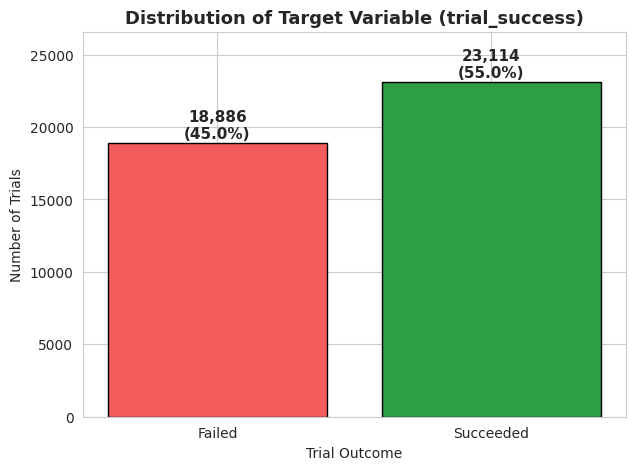

In [9]:
# create a copy of the data with readable labels to be used for plots
plot_df = df.copy()
plot_df["outcome"] = plot_df["trial_success"].map({0: "Failed", 1: "Succeeded"})
outcome_order = ["Failed", "Succeeded"]
outcome_colors = {"Failed": FAIL_COLOR, "Succeeded": SUCCESS_COLOR}

# count and percent for each class
counts = plot_df["outcome"].value_counts()[outcome_order]
percents = counts / counts.sum() * 100

# class balance of the target variable visual
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(counts.index, counts.values,
              color=[FAIL_COLOR, SUCCESS_COLOR], edgecolor="black")

# make the count and percent show on top of each bar
for bar, count, pct in zip(bars, counts.values, percents.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f"{count:,}\n({pct:.1f}%)", ha="center", fontsize=11, fontweight="bold")

# set plot title and axes
ax.set_title("Distribution of Target Variable (trial_success)")
ax.set_xlabel("Trial Outcome")
ax.set_ylabel("Number of Trials")
ax.set_ylim(0, counts.max() * 1.15)   # leave room for the labels
plt.show()

### Describe the Predictor Variables

`trial_id` is only an identifier. It will **not** be used as a predictor.

| Variable | Type | Description |
|---|---|---|
| therapeutic_area | Categorical (9 levels) | Disease area: oncology, cardiovascular, cns, infectious_disease, immunology, metabolic, respiratory, rare_disease, vaccine |
| endpoint_type | Categorical (3 levels) | hard_survival (hardest), clinical, surrogate (easiest) |
| sponsor_type | Categorical (4 levels) | large_pharma, mid_pharma, small_biotech, academic |
| phase2_effect_size | Numeric (0–10) | Strength of the Phase 2 efficacy signal |
| phase2_pvalue_strength | Numeric (0–10) | Strength of the Phase 2 statistical evidence |
| enrollment | Numeric (integer) | Number of patients enrolled |
| statistical_power | Numeric (0–1) | Statistical power of the trial |
| prior_approvals_target | Numeric (count) | Number of approved drugs on the same target |
| years_in_development | Numeric | Years the program has been in development |
| uses_biomarker | Binary (0/1) | Biomarker-guided patient selection |
| novel_mechanism | Binary (0/1) | First-in-class mechanism |
| randomized | Binary (0/1) | Trial is randomized |
| double_blind | Binary (0/1) | Trial is double-blind |
| active_comparator | Binary (0/1) | Compared against an active drug instead of placebo |
| orphan_designation | Binary (0/1) | Has orphan-drug designation |

**Summary:** 15 Total Predictors - 3 categorical, 6 numeric, and 6 binary

In [10]:
# put the columns into groups so they are easier to work with later
categorical_cols = ["therapeutic_area", "endpoint_type", "sponsor_type"]

numeric_cols = ["phase2_effect_size", "phase2_pvalue_strength", "enrollment",
                "statistical_power", "prior_approvals_target", "years_in_development"]

binary_cols = ["uses_biomarker", "novel_mechanism", "randomized",
               "double_blind", "active_comparator", "orphan_designation"]

print("Categorical:", len(categorical_cols))
print("Numeric:", len(numeric_cols))
print("Binary:", len(binary_cols))
print("Total predictors:", len(categorical_cols) + len(numeric_cols) + len(binary_cols))

Categorical: 3
Numeric: 6
Binary: 6
Total predictors: 15


### Compute Descriptive Statistics

In [11]:
# summary statistics for numeric predictors
df[numeric_cols].describe().round(2)

,phase2_effect_size,phase2_pvalue_strength,enrollment,statistical_power,prior_approvals_target,years_in_development
count,42000.00,42000.00,42000.00,42000.00,42000.0,42000.00
mean,5.00,6.91,601.29,0.82,1.2,6.99
std,1.98,2.01,422.74,0.10,1.1,2.50
min,0.00,0.00,40.00,0.40,0.0,1.00
25%,3.64,5.54,290.00,0.75,0.0,5.30
50%,4.99,6.98,504.00,0.82,1.0,7.00
75%,6.33,8.44,811.00,0.89,2.0,8.70
max,10.00,10.00,4194.00,0.99,9.0,17.00


In [12]:
# for binary predictors, the mean is the proportion of trials with a value of 1
df[binary_cols].mean().round(3).to_frame("calculated_mean")

,calculated_mean
uses_biomarker,0.417
novel_mechanism,0.418
randomized,0.880
double_blind,0.720
active_comparator,0.495
orphan_designation,0.181


In [13]:
# counts for each categorical predictor
for col in categorical_cols:
    print(df[col].value_counts())
    print()

therapeutic_area
oncology              10872
cns                    4975
infectious_disease     4277
cardiovascular         4167
rare_disease           3812
immunology             3784
metabolic              3671
vaccine                3461
respiratory            2981
Name: count, dtype: int64

endpoint_type
clinical         16771
surrogate        12717
hard_survival    12512
Name: count, dtype: int64

sponsor_type
small_biotech    14436
large_pharma     14155
mid_pharma        8472
academic          4937
Name: count, dtype: int64



In [14]:
# compare the average of each numeric predictor for failed vs. successful trials
df.groupby("trial_success")[numeric_cols].mean().round(2)

,phase2_effect_size,phase2_pvalue_strength,enrollment,statistical_power,prior_approvals_target,years_in_development
trial_success,,,,,,
0,4.60,6.57,592.21,0.81,1.13,7.00
1,5.32,7.19,608.71,0.83,1.26,6.99


**Descriptive Statistics Observations:**

*Numeric predictors*
- **phase2_effect_size** (mean 5.00, SD 1.98) is centred in the middle of its 0–10 scale.
  Its mean and median are almost the same (5.00 vs 4.99), so it's close to symmetric.
- **phase2_pvalue_strength** (mean 6.91) is shifted toward the top of its scale, with
  75% of trials scoring 5.54 or higher.
- **enrollment** varies the most, from 40 to 4,194 patients. The mean (601) is well above
  the median (504), which shows right skew, so a few very large trials pull the mean up.
- **statistical_power** ranges from 0.40 to 0.99 (mean 0.82). Most trials are designed
  with the usual 80% power or more.
- **prior_approvals_target** is a small count (median 1, max 9).
- **years_in_development** averages about 7 years (range 1–17).

*Binary predictors*
- Most trials are randomized (88%) and double-blinded (72%).
- Only 18.1% have orphan-drug designation.
- Biomarker use (41.7%), novel mechanism (41.8%), and active comparator (49.5%) are more evenly split.

*Categorical predictors*
- Oncology is the largest therapeutic area (10,872 trials, 25.9%). The smallest therapeutic area, respiratory, still has 2,981 trials (7.1%), so every category has plenty of data.
- Endpoints: clinical 39.9%, surrogate 30.3%, hard_survival 29.8%.
- Sponsors: small biotech 34.4%, large pharma 33.7%, mid pharma 20.2%, academic 11.8%.

*Successful vs. failed trials*
- Successful trials had a stronger average Phase 2 effect size (5.32 vs 4.60) and stronger Phase 2 p-value strength (7.19 vs 6.57). These are the biggest differences.
- Successful trials also had slightly higher average statistical power (0.83 vs 0.81) and more prior approvals on the same target (1.26 vs 1.13).
- Enrollment differs only slightly (609 vs 592), and average years in development shows no difference (6.99 vs 7.00).

### Exploratory Visualizations

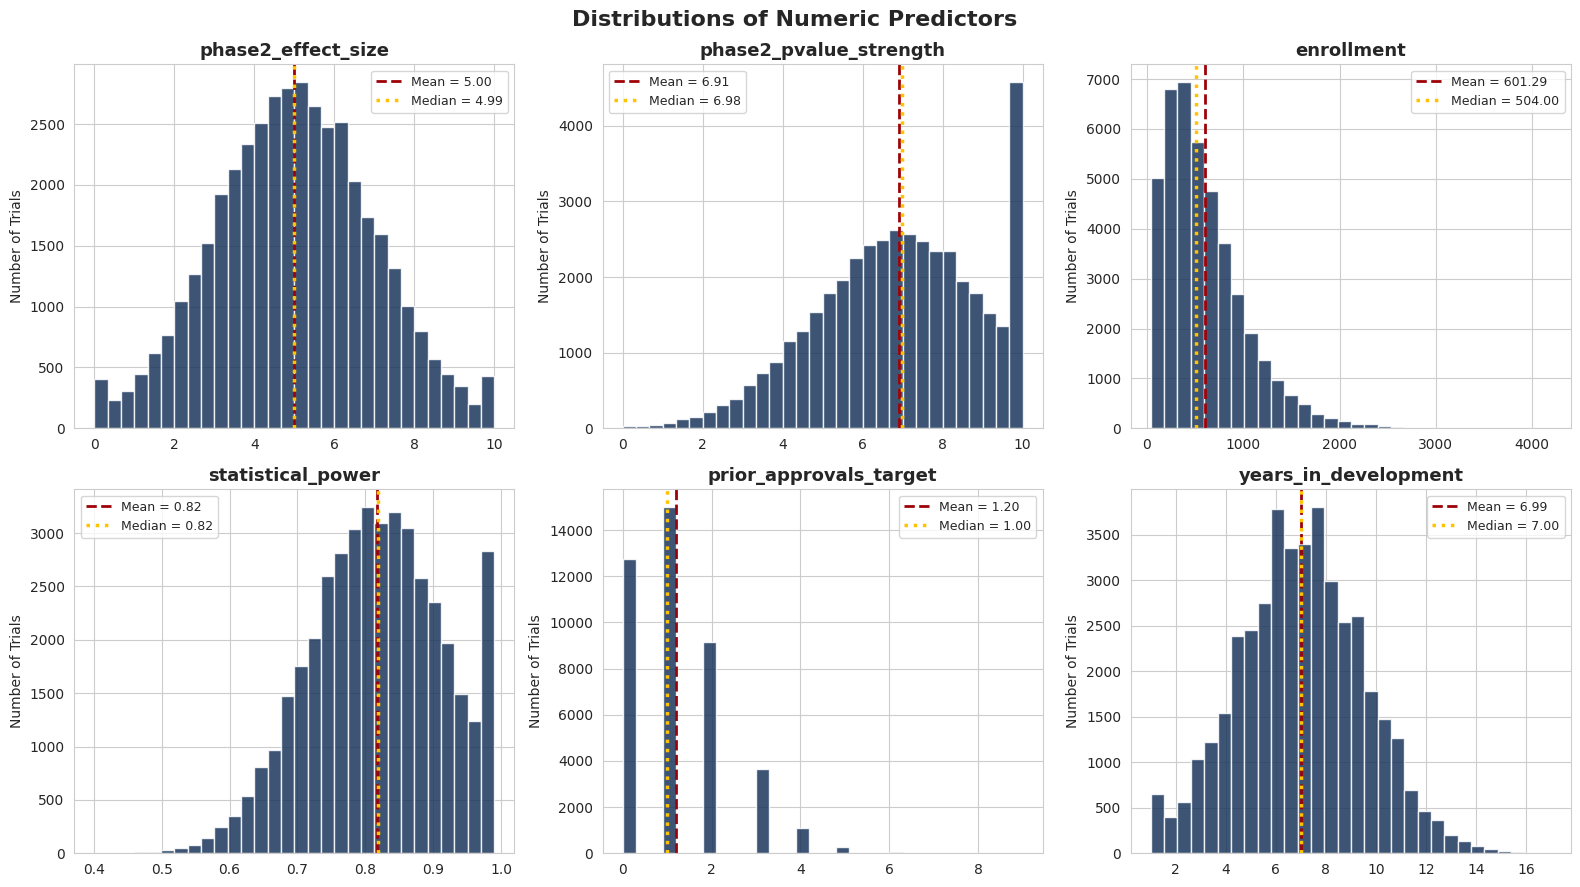

In [15]:
# histograms of the numeric predictors
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    ax.hist(df[col], bins=30, color=MAIN_COLOR, edgecolor="white", alpha=0.85)

    # add mean and median lines
    mean_value = df[col].mean()
    median_value = df[col].median()
    ax.axvline(mean_value, color=MEAN_COLOR, linestyle="--", linewidth=2,
               label=f"Mean = {mean_value:.2f}")
    ax.axvline(median_value, color=MEDIAN_COLOR, linestyle=":", linewidth=2.5,
               label=f"Median = {median_value:.2f}")

    ax.set_title(col)
    ax.set_ylabel("Number of Trials")
    ax.legend(fontsize=9)

plt.suptitle("Distributions of Numeric Predictors", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

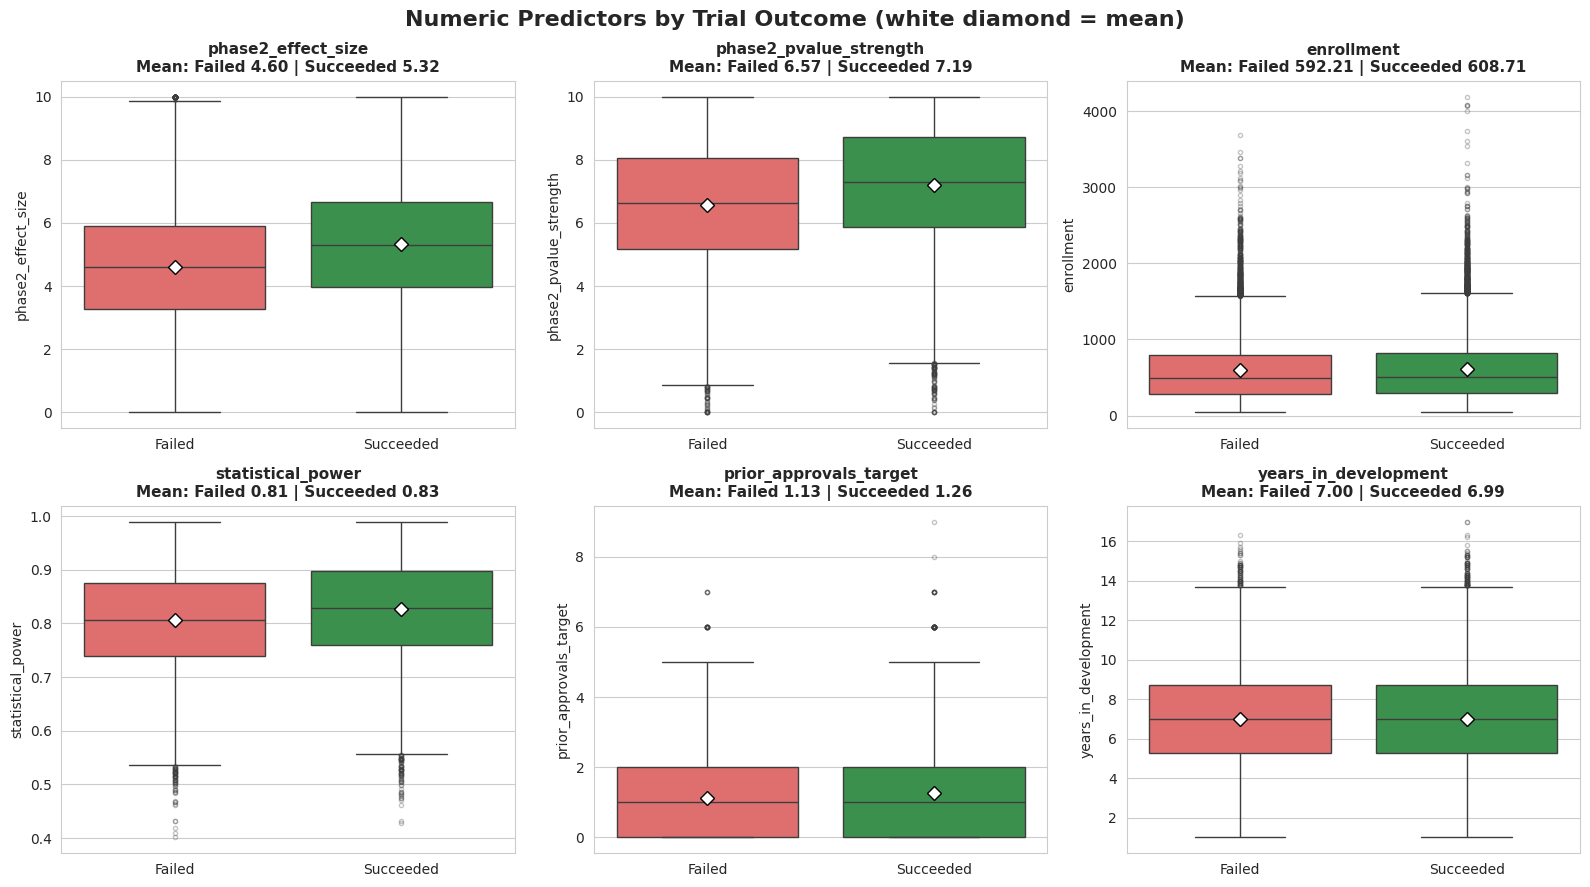

In [16]:
# boxplots of numeric predictors split by trial outcome
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=plot_df, x="outcome", y=col, hue="outcome",
                order=outcome_order, palette=outcome_colors, legend=False,
                showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white",
                           "markeredgecolor": "black", "markersize": 7},
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.3},
                ax=axes[i])

    # group means in the title
    mean_fail = df[df["trial_success"] == 0][col].mean()
    mean_success = df[df["trial_success"] == 1][col].mean()
    axes[i].set_title(f"{col}\nMean: Failed {mean_fail:.2f} | Succeeded {mean_success:.2f}",
                      fontsize=11)
    axes[i].set_xlabel("")

plt.suptitle("Numeric Predictors by Trial Outcome (white diamond = mean)",
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

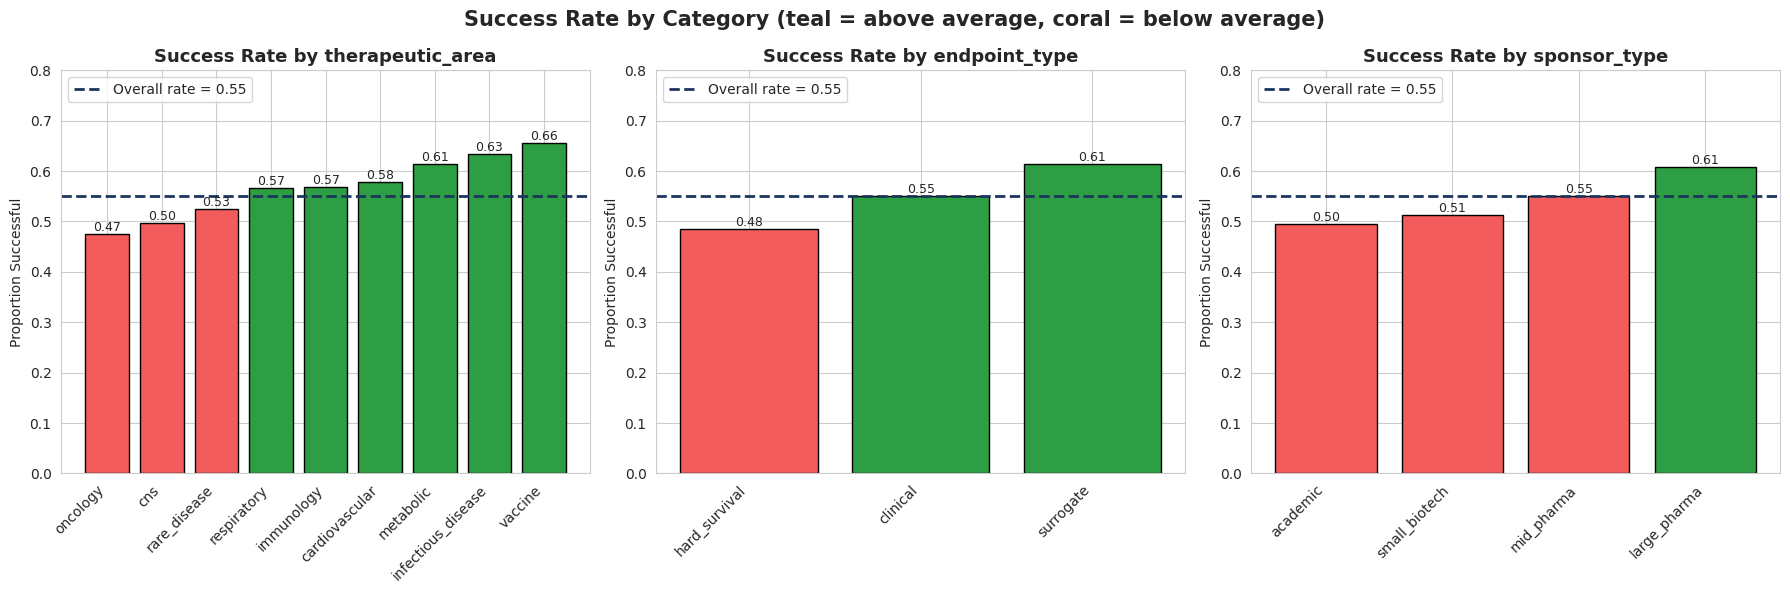

In [17]:
# overall success rate for reference line
overall_rate = df["trial_success"].mean()

# visual for success rate for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    success_rate = df.groupby(col)["trial_success"].mean().sort_values()

    # color for success if above the overall rate
    # color for failure if below the overall rate
    bar_colors = []
    for rate in success_rate:
        if rate >= overall_rate:
            bar_colors.append(SUCCESS_COLOR)
        else:
            bar_colors.append(FAIL_COLOR)

    bars = ax.bar(success_rate.index, success_rate.values,
                  color=bar_colors, edgecolor="black")
    ax.bar_label(bars, fmt="%.2f", fontsize=9)    # value on top of each bar

    ax.axhline(overall_rate, color=MAIN_COLOR, linestyle="--", linewidth=2,
               label=f"Overall rate = {overall_rate:.2f}")

    ax.set_title("Success Rate by " + col)
    ax.set_ylabel("Proportion Successful")
    ax.set_ylim(0, 0.8)
    ax.legend(loc="upper left")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Success Rate by Category (teal = above average, coral = below average)",
             fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

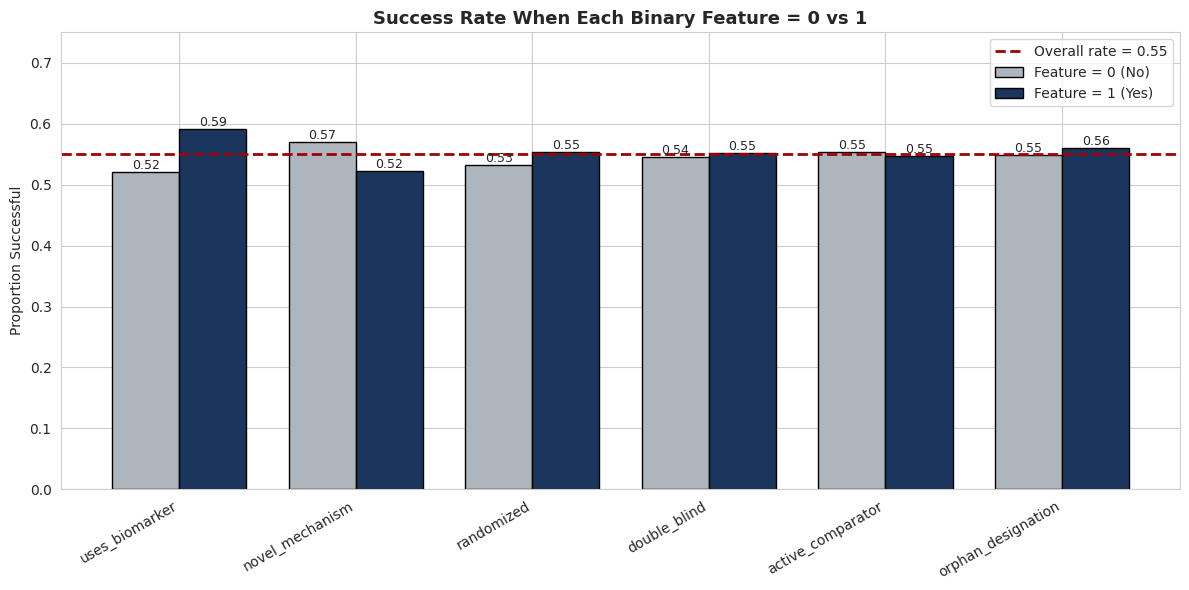

In [18]:
# success rate when each binary feature is 0 vs 1
rate_when_0 = []
rate_when_1 = []
for col in binary_cols:
    rates = df.groupby(col)["trial_success"].mean()
    rate_when_0.append(rates[0])
    rate_when_1.append(rates[1])

overall_rate = df["trial_success"].mean()

# visual for side-by-side bars
x = np.arange(len(binary_cols))   # one position per feature
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))
bars0 = ax.bar(x - width / 2, rate_when_0, width, label="Feature = 0 (No)",
               color="#ADB5BD", edgecolor="black")
bars1 = ax.bar(x + width / 2, rate_when_1, width, label="Feature = 1 (Yes)",
               color=MAIN_COLOR, edgecolor="black")
ax.bar_label(bars0, fmt="%.2f", fontsize=9)
ax.bar_label(bars1, fmt="%.2f", fontsize=9)

ax.axhline(overall_rate, color=MEAN_COLOR, linestyle="--", linewidth=2,
           label=f"Overall rate = {overall_rate:.2f}")

ax.set_xticks(x)
ax.set_xticklabels(binary_cols, rotation=30, ha="right")
ax.set_ylim(0, 0.75)
ax.set_ylabel("Proportion Successful")
ax.set_title("Success Rate When Each Binary Feature = 0 vs 1")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [19]:
# exact success rates for each category
# supporting data for visuals
for col in categorical_cols + binary_cols:
    print("----", col, "----")
    print(df.groupby(col)["trial_success"].mean().round(3))
    print()

---- therapeutic_area ----
therapeutic_area
cardiovascular        0.579
cns                   0.496
immunology            0.568
infectious_disease    0.634
metabolic             0.614
oncology              0.474
rare_disease          0.525
respiratory           0.567
vaccine               0.655
Name: trial_success, dtype: float64

---- endpoint_type ----
endpoint_type
clinical         0.550
hard_survival    0.485
surrogate        0.615
Name: trial_success, dtype: float64

---- sponsor_type ----
sponsor_type
academic         0.495
large_pharma     0.608
mid_pharma       0.550
small_biotech    0.513
Name: trial_success, dtype: float64

---- uses_biomarker ----
uses_biomarker
0    0.521
1    0.592
Name: trial_success, dtype: float64

---- novel_mechanism ----
novel_mechanism
0    0.571
1    0.522
Name: trial_success, dtype: float64

---- randomized ----
randomized
0    0.532
1    0.553
Name: trial_success, dtype: float64

---- double_blind ----
double_blind
0    0.545
1    0.553
Name: tri

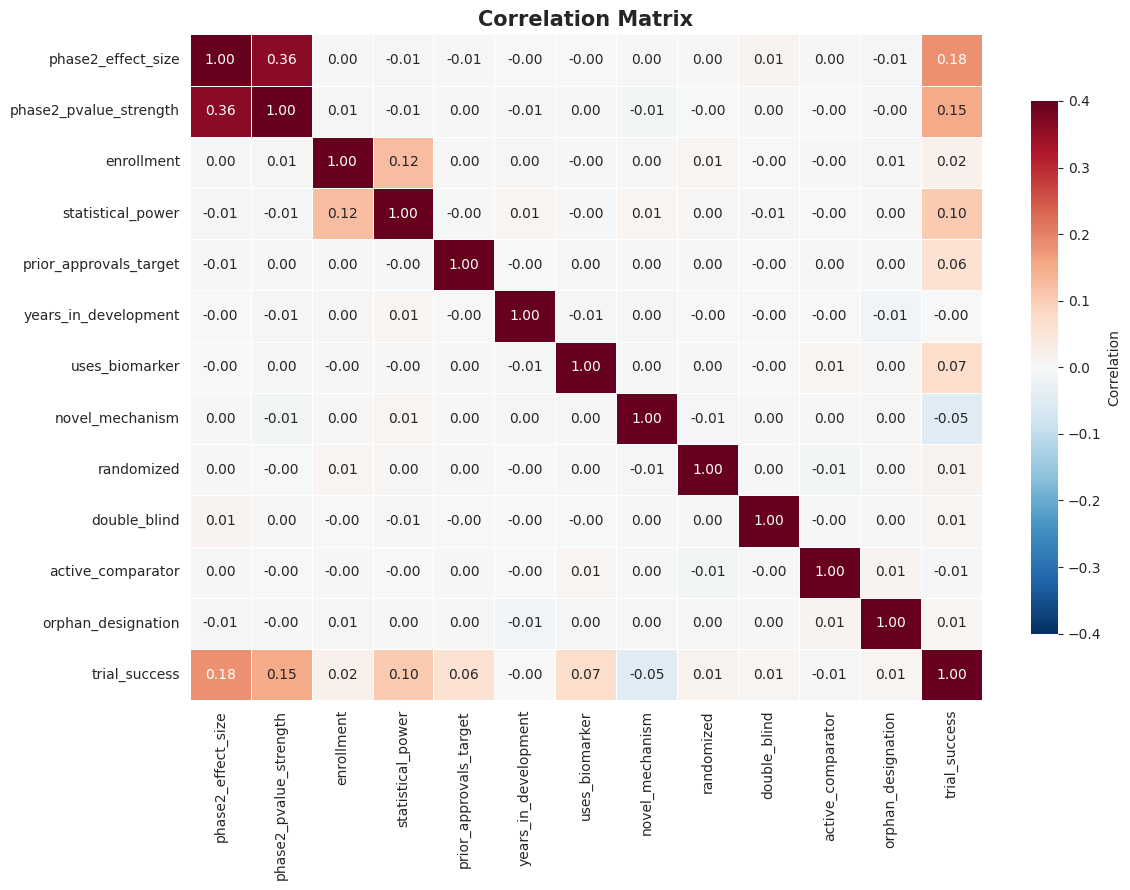

In [20]:
# correlation heatmap
corr = df[numeric_cols + binary_cols + ["trial_success"]].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, vmin=-0.4, vmax=0.4,
            linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Correlation", "shrink": 0.8})
plt.title("Correlation Matrix", fontsize=15)
plt.tight_layout()
plt.show()

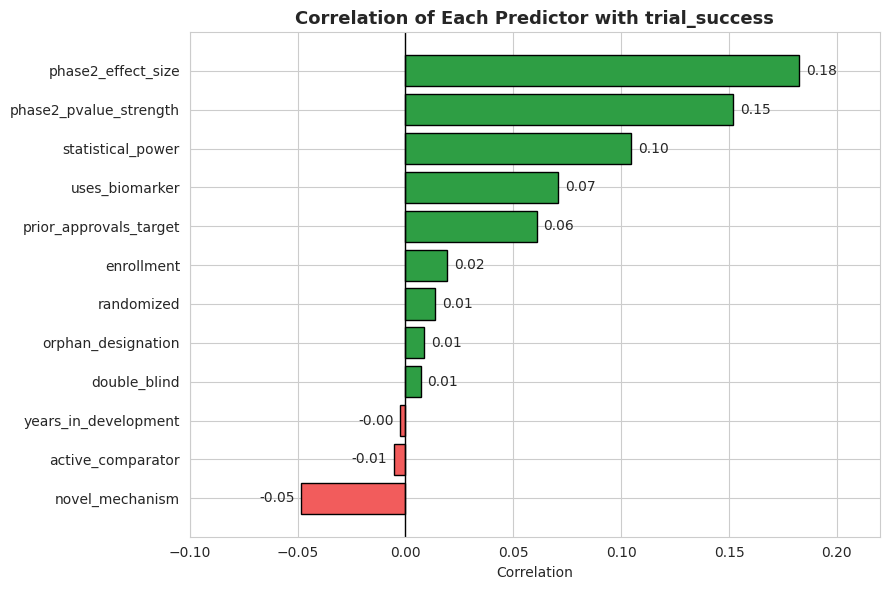

In [21]:
# how strongly is each predictor correlated with trial_success?
target_corr = corr["trial_success"].drop("trial_success").sort_values()

# success color indicates a positive relationship
# failure color indicates a negative relationship
bar_colors = []
for value in target_corr:
    if value > 0:
        bar_colors.append(SUCCESS_COLOR)
    else:
        bar_colors.append(FAIL_COLOR)

plt.figure(figsize=(9, 6))
plt.barh(target_corr.index, target_corr.values, color=bar_colors, edgecolor="black")
plt.axvline(0, color="black", linewidth=1)

# values will display next to each bar
for i, value in enumerate(target_corr.values):
    if value >= 0:
        plt.text(value + 0.003, i, f"{value:.2f}", va="center", ha="left")
    else:
        plt.text(value - 0.003, i, f"{value:.2f}", va="center", ha="right")

plt.title("Correlation of Each Predictor with trial_success")
plt.xlabel("Correlation")
plt.xlim(-0.1, 0.22)
plt.tight_layout()
plt.show()

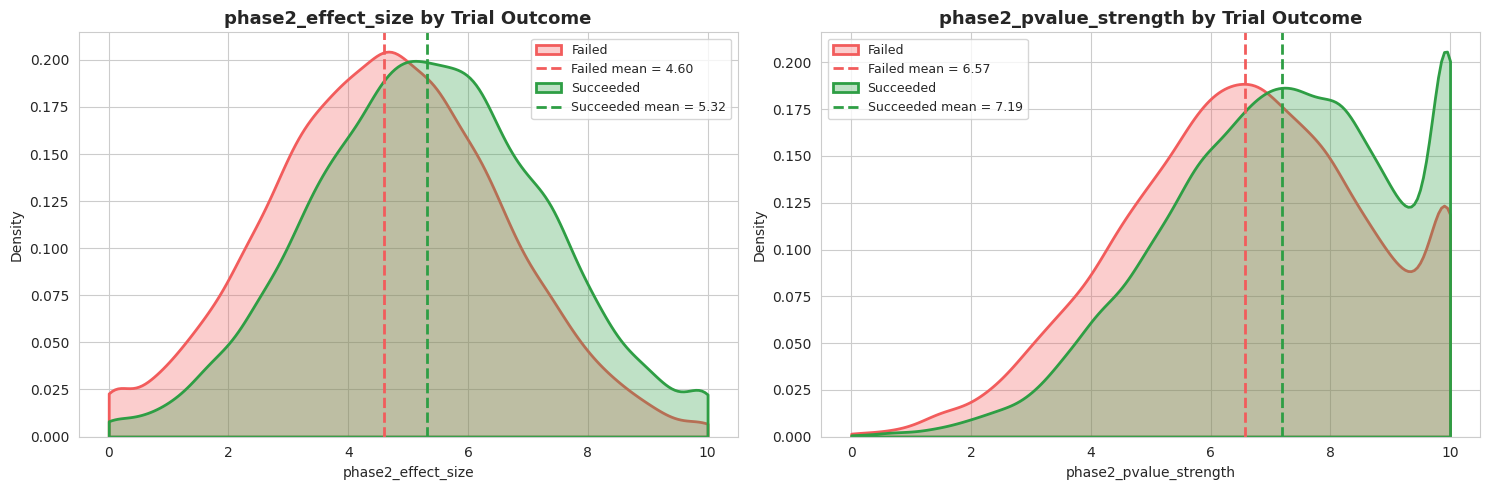

In [22]:
# visual to compare failed vs. successful trials for the top 2 predictors
top_predictors = ["phase2_effect_size", "phase2_pvalue_strength"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(top_predictors):
    ax = axes[i]
    for outcome in outcome_order:
        values = plot_df[plot_df["outcome"] == outcome][col]
        sns.kdeplot(values, ax=ax, color=outcome_colors[outcome], fill=True,
                    alpha=0.3, linewidth=2, clip=(0, 10), label=outcome)
        ax.axvline(values.mean(), color=outcome_colors[outcome], linestyle="--",
                   linewidth=2, label=f"{outcome} mean = {values.mean():.2f}")

    ax.set_title(col + " by Trial Outcome")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Visualization Key Points:**

**Target distribution:** The classes are fairly balanced, with about 55% successful and
45% failed trials. We don't need to rebalance the
classes, but a model must beat the 55% baseline of always guessing "success" to be useful.

**Histograms:**
- **phase2_effect_size** looks roughly bell-shaped, with small spikes at exactly 0 and 10.
- **phase2_pvalue_strength** is left-skewed, with a large spike at 10. Values seem to have been capped at the maximum of the scale.
- **enrollment** is strongly right-skewed, with a long tail out past 4,000.
- **statistical_power** has a spike at 0.99, which looks like another cap.
- **prior_approvals_target** is a right-skewed count. Most trials have 0–2.
- **years_in_development** is roughly bell-shaped, with a small pile-up at 1 year (a possible minimum cap).
- For `enrollment`, the mean line (601) is clearly to the right of the
  median line (504), which confirms the right skew. For `phase2_effect_size` the two
  lines nearly overlap, so it is close to symmetric.

**Boxplots by trial success:**
- Successful trials have clearly higher medians for **phase2_effect_size** and
  **phase2_pvalue_strength**, and a slightly higher median for **statistical_power**.
- The boxes for **enrollment**, **prior_approvals_target** and **years_in_development**
  look almost identical in the two groups.
- The two classes **overlap a lot** on every variable, so no single feature separates
  them well.
- The white diamonds show the means. The gap between failed and successful
  trials is clearest for phase2_effect_size (4.60 vs 5.32) and phase2_pvalue_strength
  (6.57 vs 7.19).

**Success rate by category:**

All three categorical variables show clear differences:
- *Therapeutic area:* oncology has the lowest success rate (approx. 47%) and vaccines the highest (approx. 65%).
- *Endpoint type:* hard_survival approx. 48%, clinical approx. 55%, surrogate approx. 61%. This matches the
  data dictionary, which ranks survival endpoints as the hardest to meet.
- *Sponsor type:* academic approx. 50%, small biotech approx. 51%, mid pharma approx. 55%, large pharma approx. 61%.
- The dashed line marks the overall success rate.
  Bars above it are categories that do better than average. Oncology, CNS, hard_survival
  endpoints, academic sponsors and novel mechanisms fall below average. Vaccines,
  surrogate endpoints, large pharma and biomarker use are above average.

**Success rate for binary features:**
- **uses_biomarker** gives the biggest increase (approx. 52% to approx. 59%).
- **novel_mechanism** lowers success (approx. 57% to approx. 52%), as expected for first-in-class drugs.
- **randomized, double_blind, active_comparator** and **orphan_designation** make almost
  no difference (each changes the success rate by about 2 percentage points or less).

**Correlation heatmap:**
- The color scale is set to −0.4 to 0.4, instead of −1 to 1, so the small correlations are visible.
- The predictors most correlated with the target are phase2_effect_size (0.18),
  phase2_pvalue_strength (0.15), statistical_power (0.10), uses_biomarker (0.07),
  prior_approvals_target (0.06) and novel_mechanism (−0.05). All of these are weak correlations.
- The only notable link between two predictors is effect size and p-value strength
  (0.36), followed by enrollment and statistical power (0.12). All other pairs are near 0,
  so multicollinearity is not a concern.

**Correlation with the target:**
- Phase 2 effect size (0.18) and Phase 2 p-value
strength (0.15) are the strongest predictors, followed by statistical power (0.10).
- novel_mechanism is the only clearly negative predictor (−0.05).
- Several features are close to 0.

**Density curves:**
- The successful-trial curves sit slightly to the right of the failed-trial curves for both Phase 2 measures.
- The curves still overlap heavily, which shows why a model needs to combine several features.
- The bump near 10 on phase2_pvalue_strength reflects the capped values.

## Data Quality Assessment

In [23]:
# count of missing values in each column
missing = df.isnull().sum()
print(missing)
print("\nTotal missing values:", missing.sum())

trial_id                  0
therapeutic_area          0
uses_biomarker            0
phase2_effect_size        0
phase2_pvalue_strength    0
endpoint_type             0
enrollment                0
statistical_power         0
sponsor_type              0
novel_mechanism           0
prior_approvals_target    0
randomized                0
double_blind              0
active_comparator         0
years_in_development      0
orphan_designation        0
trial_success             0
dtype: int64

Total missing values: 0


In [24]:
# count of duplicate rows and duplicate IDs
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate trial IDs:", df["trial_id"].duplicated().sum())

Duplicate rows: 0
Duplicate trial IDs: 0


In [25]:
# check that binary columns only contain 0 and 1
for col in binary_cols + ["trial_success"]:
    print(col, "->", df[col].unique())

uses_biomarker -> [0 1]
novel_mechanism -> [1 0]
randomized -> [1 0]
double_blind -> [0 1]
active_comparator -> [1 0]
orphan_designation -> [0 1]
trial_success -> [1 0]


In [26]:
# check that numeric columns stay inside their expected ranges
print("phase2_effect_size outside 0-10:",
      ((df["phase2_effect_size"] < 0) | (df["phase2_effect_size"] > 10)).sum())
print("phase2_pvalue_strength outside 0-10:",
      ((df["phase2_pvalue_strength"] < 0) | (df["phase2_pvalue_strength"] > 10)).sum())
print("statistical_power outside 0-1:",
      ((df["statistical_power"] < 0) | (df["statistical_power"] > 1)).sum())
print("enrollment <= 0:", (df["enrollment"] <= 0).sum())
print("prior_approvals_target < 0:", (df["prior_approvals_target"] < 0).sum())
print("years_in_development < 0:", (df["years_in_development"] < 0).sum())

phase2_effect_size outside 0-10: 0
phase2_pvalue_strength outside 0-10: 0
statistical_power outside 0-1: 0
enrollment <= 0: 0
prior_approvals_target < 0: 0
years_in_development < 0: 0


In [27]:
# check for typos or extra spaces in category labels
for col in categorical_cols:
    print(col, "->", sorted(df[col].unique()))

therapeutic_area -> ['cardiovascular', 'cns', 'immunology', 'infectious_disease', 'metabolic', 'oncology', 'rare_disease', 'respiratory', 'vaccine']
endpoint_type -> ['clinical', 'hard_survival', 'surrogate']
sponsor_type -> ['academic', 'large_pharma', 'mid_pharma', 'small_biotech']


In [28]:
# many values appear to be exactly 10.0 (the maximum), so the scale may be capped
for col in ["phase2_effect_size", "phase2_pvalue_strength"]:
    n_max = (df[col] == 10).sum()
    print(col, "values equal to 10:", n_max, "(", round(n_max / len(df) * 100, 2), "% )")

print("statistical_power values equal to 0.99 or higher:", (df["statistical_power"] >= 0.99).sum())

phase2_effect_size values equal to 10: 268 ( 0.64 % )
phase2_pvalue_strength values equal to 10: 3508 ( 8.35 % )
statistical_power values equal to 0.99 or higher: 1893


In [29]:
# find outliers with the IQR rule
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(col, "outliers:", n_outliers)

phase2_effect_size outliers: 0
phase2_pvalue_strength outliers: 134
enrollment outliers: 1282
statistical_power outliers: 138
prior_approvals_target outliers: 65
years_in_development outliers: 162


### Data Quality Findings
| Check | Result |
|---|---|
| Missing values | **0** in all 17 columns |
| Duplicate rows / duplicate trial IDs | **0 / 0** |
| Binary columns contain only 0 and 1 | Yes, all 7 (6 predictors + target) |
| Numeric values inside expected ranges | Yes, 0 out-of-range values |
| Category labels clean (no typos or extra spaces) | Yes. 9, 3 and 4 levels, matching the data dictionary |
| Values at the maximum of 10: phase2_pvalue_strength | **3,508 (8.35%)** |
| Values at the maximum of 10: phase2_effect_size | 268 (0.64%) |
| statistical_power at 0.99 or higher | 1,893 (4.5%) |
| IQR outliers: enrollment | **1,282 (3.1%)** |
| IQR outliers: other numeric columns | 65–162 each (under 0.4%) |

**Summary:** The dataset is very clean. Nothing is missing, duplicated, or coded wrongly.

The main issues are:
1. **Ceiling effects (capped values):** Many values sit at exactly the top of their scale
   (10 for p-value strength, 0.99 for power). Small spikes at 0 for effect size and at
   1 year for years_in_development suggest values were also capped at the bottom.
2. **Outliers in enrollment:** The 1,282 large trials look like real values, not errors,
   since big Phase 3 trials with thousands of patients do exist, so these values will be kept for the analysis.

### Anticipated Preprocessing Steps
1. **Drop `trial_id`.** It is a unique label with no predictive value.
2. No missing-value imputation or dropping of records needed. It has been confirmed there are 0 missing values.
3. No recoding needed. All binary and categorical values are valid.
4. Encode `endpoint_type` in order. (surrogate = 0, clinical = 1, hard_survival = 2).
   The success rates fall steadily from surrogate to hard_survival, so this order is meaningful.
5. Log-transform `enrollment` (`np.log1p`) to reduce its right skew. Keep the
   outliers instead of removing them because they are real values.
6. Scale numeric features with `StandardScaler` for logistic regression and KNN, if used.
   Variables use very different scales (enrollment in the hundreds or thousands, power 0–1). If used, tree-based models don't need scaling.
7. Consider potentially adding indicator columns for capped values. For example,
   `pvalue_at_max = 1` if phase2_pvalue_strength equals 10. This lets the model treat those 8.35% of trials differently.
8. Keep all features for now, even though randomized, double_blind, active_comparator,
    orphan_designation, and years_in_development showed almost no relationship with the target. I will decide later after checking feature importance whether to remove them.

### Potential Challenges
- **Weak individual signals:** The strongest correlation with the target is only 0.18,
  and the classes overlap a lot in every boxplot. This should lead to moderate, rather than very high
  accuracy. The model will need to combine many weak signals.
- **Several uninformative features:** About 5 of the 15 predictors show almost no
  relationship with the target. This could add noise or lead to overfitting.
- **Ceiling effects:** Capping at 10 and 0.99 hides differences among the strongest
  trials and could flatten the relationship at the top of the scale.
- **Skewed enrollment with outliers:** This could distort distance-based or linear
  models (if applicable) if left untransformed.
- **Moderate overlap between Phase 2 measures:** Effect size and p-value strength are
  correlated (r = 0.36). This should be considered when interpreting logistic regression coefficients, if used.
- **Synthetic data:** The data appears to be simulated, so findings may not carry
  over to real clinical trials.
- **Mixed variable types:** Categorical, binary, and numeric predictors each need their own preprocessing.

## Project Planning

### Proposed prediction problem
Using information available before a Phase 3 trial begins (Phase 2 results, trial design, sponsor and drug characteristics), predict whether the trial will meet its primary endpoint (be successful).

### Target variable
`trial_success`: binary (1 = success, 0 = failure).

### Candidate evaluation metrics
- **Primary metric: ROC-AUC.** Because the signals are weak, a metric is needed that
  measures how well the model ranks trials by their chance of success across all
  thresholds, not just at one cutoff.
- **Baseline to beat:** about 55% accuracy (always predicting "success") and an
  ROC-AUC of 0.50 (random guessing).
- **Secondary metrics:** accuracy, precision, recall, F1-score and a confusion matrix.
  The classes are reasonably balanced (55/45), so accuracy is meaningful as long as it is
  compared with the baseline.
- **Recall for failed trials** matters to sponsors because missing a trial that will
  fail is a very expensive mistake.

## Summary
The dataset has 42,000 Phase 3 trials, 15 predictors and a binary target that is
reasonably balanced (about 55% success), so it meets all project requirements. The data
is very clean with no missing values, duplicates, or improperly coded entries. The
main data issues are capped values (8.35% of p-value strength scores equal 10) and a
right-skewed enrollment variable.

The strongest predictors of success appear to be Phase 2 effect size, Phase 2 p-value
strength, statistical power, biomarker use, endpoint type, sponsor type, and therapeutic
area. Trial design variables (randomization, blinding, comparator type), orphan status,
and years in development show almost no relationship with the outcome. Since every
individual relationship is weak, the next step is to build models that combine these
predictors and judge them by ROC-AUC against the 55% baseline.

#### AI-Usage Statement:

I utilized Claude Opus 5.5 to help write and customize the visualization code (mean and median lines, value labels, and reference lines). I ran all the code myself and checked the output and assisted interpretations.